# 📊 Generate Output Notebook (Final - IEEE Ready)

This notebook:
- Cleans and processes research data
- Generates IEEE-ready tables
- Produces advanced analysis graphs
- Exports LaTeX tables


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

## 📂 Load Dataset

In [46]:
df = pd.read_csv('research_data.csv')
df.columns = df.columns.str.strip()
df.head()

,id,username,filename,algorithm,size_kb,latency_ms,packets_lost,real_latency_ms,data_type,clumsy_lag_ms,clumsy_drop_pct
0,1,AutoBot_Text_IoT,Text_IoT_data.bin,Hybrid PQC,3.04,19.55,0,164.20,Text_IoT,0.0,0.0
1,2,AutoBot_Text_IoT,Text_IoT_data.bin,Hybrid PQC,3.02,19.53,0,96.26,Text_IoT,0.0,0.0
2,3,AutoBot_Text_IoT,Text_IoT_data.bin,Hybrid PQC,3.03,19.54,0,94.80,Text_IoT,0.0,0.0
3,4,AutoBot_Text_IoT,Text_IoT_data.bin,Standard AES,2.77,17.77,0,118.81,Text_IoT,0.0,0.0
4,5,AutoBot_Text_IoT,Text_IoT_data.bin,Standard AES,2.77,17.77,0,109.16,Text_IoT,0.0,0.0


## 🧹 Data Cleaning

In [47]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

df['latency_ms'] = df['latency_ms'].round(2)
df['real_latency_ms'] = df['real_latency_ms'].round(2)

## 📊 Table 1: Algorithm Performance

In [48]:
summary = df.groupby('algorithm').agg({
    'latency_ms': ['mean','std'],
    'real_latency_ms':'mean',
    'packets_lost':'mean',
    'size_kb':'mean'
}).reset_index()

summary.columns = ['Algorithm','Sim_Latency_Mean','Sim_Latency_STD','Real_Latency_Mean','Avg_Packet_Loss','Avg_File_Size']
summary


,Algorithm,Sim_Latency_Mean,Sim_Latency_STD,Real_Latency_Mean,Avg_Packet_Loss,Avg_File_Size
0,Hybrid PQC,6013.719700,9588.472196,3643.677291,12.905967,3999.146535
1,Standard AES,5552.867565,8606.570302,3596.902135,5.373687,5537.867565


In [49]:
summary.to_csv('tables/table_performance.csv', index=False, float_format='%.2f')

## 📊 Table 2: Payload Latency

In [50]:
payload_table = df.groupby(['data_type','algorithm'])['real_latency_ms'].mean().reset_index()
payload_table


,data_type,algorithm,real_latency_ms
0,Document_PDF,Hybrid PQC,1360.564896
1,Document_PDF,Standard AES,1388.958486
2,HD_Video,Hybrid PQC,9613.913757
3,HD_Video,Standard AES,9362.479216
4,High_Res_Image,Hybrid PQC,5753.562840
5,High_Res_Image,Standard AES,5345.120620
6,Manual_Web_Upload,Hybrid PQC,900.500000
7,Text_IoT,Hybrid PQC,1211.652380
8,Text_IoT,Standard AES,1235.128078


In [51]:
payload_table.to_csv('tables/table_payload.csv', index=False, float_format='%.2f')

## 📊 Table 3: Packet Loss Stats

In [52]:
packet_table = df.groupby('algorithm')['packets_lost'].describe()[['mean','max','min']]
packet_table


,mean,max,min
algorithm,,,
Hybrid PQC,12.905967,1935.0,0.0
Standard AES,5.373687,2522.0,0.0


In [53]:
packet_table.to_csv('tables/table_packet_loss.csv', float_format='%.2f')

## 📊 Table 4: Tail Latency (95th Percentile)

In [54]:
tail_latency = df.groupby('algorithm')['real_latency_ms'].quantile(0.95).reset_index()
tail_latency.columns = ['Algorithm', 'Latency_95th_Percentile']
tail_latency

,Algorithm,Latency_95th_Percentile
0,Hybrid PQC,13539.328
1,Standard AES,13474.072


In [55]:
tail_latency.to_csv('tables/table_tail_latency.csv', index=False, float_format='%.2f')

## 📊 Table 5: Latency Ratio

In [56]:
mean_latency = df.groupby('algorithm')['real_latency_ms'].mean()

try:
    ratio = mean_latency['Hybrid PQC'] / mean_latency['Standard AES']
except:
    ratio = None

ratio_df = pd.DataFrame({
    'Metric': ['PQC_to_AES_Latency_Ratio'],
    'Value': [ratio]
})
mean_latency

algorithm
Hybrid PQC      3643.677291
Standard AES    3596.902135
Name: real_latency_ms, dtype: float64

In [57]:

ratio_df.to_csv('tables/table_latency_ratio.csv', index=False)

## 📊 Table 6: Packet Loss Rate

In [58]:
df['loss_rate'] = df['packets_lost'] / (df['size_kb'] + 1)

loss_rate = df.groupby('algorithm')['loss_rate'].mean().reset_index()
loss_rate.columns = ['Algorithm', 'Avg_Loss_Rate']
loss_rate

,Algorithm,Avg_Loss_Rate
0,Hybrid PQC,0.013376
1,Standard AES,0.003770


In [59]:

loss_rate.to_csv('tables/table_loss_rate.csv', index=False, float_format='%.4f')

## 📈 Graphs (Formatted - Publication Ready)

## Graph 1: Average Latency

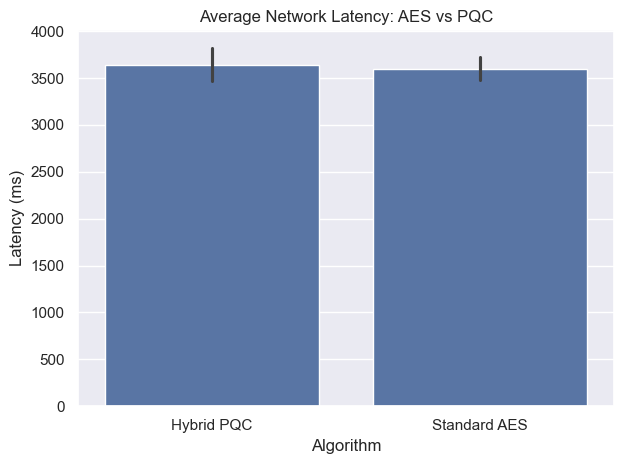

In [60]:
plt.figure()
sns.barplot(data=df, x='algorithm', y='real_latency_ms')
plt.title('Average Network Latency: AES vs PQC')
plt.xlabel('Algorithm')
plt.ylabel('Latency (ms)')
plt.tight_layout()
plt.savefig('charts/fig1_latency_bar.png', dpi=300)
plt.show()

## Graph 2: Latency Scaling

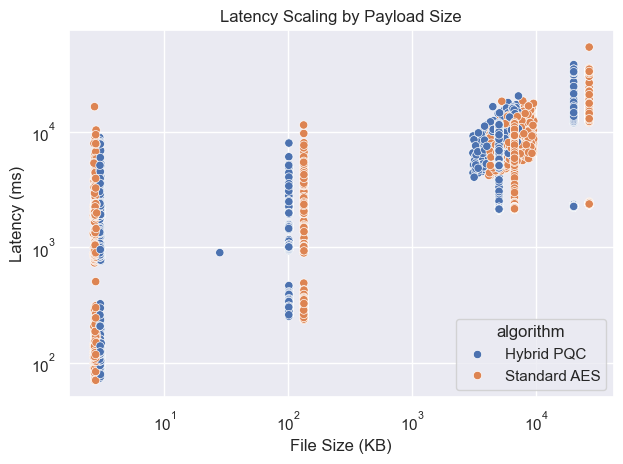

In [61]:
plt.figure()
sns.scatterplot(data=df, x='size_kb', y='real_latency_ms', hue='algorithm')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('File Size (KB)'); plt.ylabel('Latency (ms)')
plt.title('Latency Scaling by Payload Size')
plt.tight_layout()
plt.savefig('charts/fig2_latency_scatter.png', dpi=300)
plt.show()

## Graph 3: Packet Loss

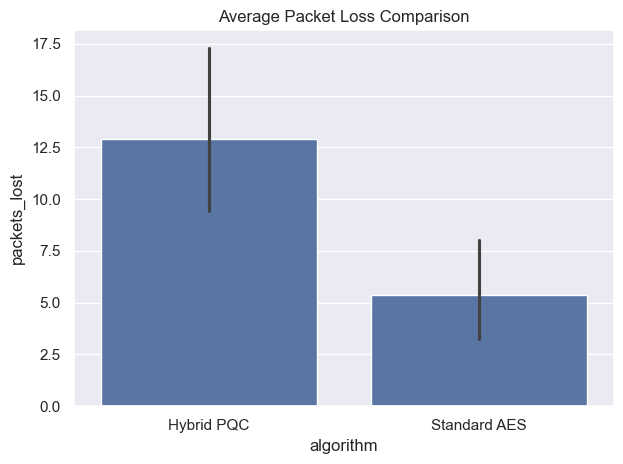

In [62]:
plt.figure()
sns.barplot(data=df, x='algorithm', y='packets_lost')
plt.title('Average Packet Loss Comparison')
plt.tight_layout()
plt.savefig('charts/fig3_packet_loss.png', dpi=300)
plt.show()

## Graph 4: AI Routing Distribution

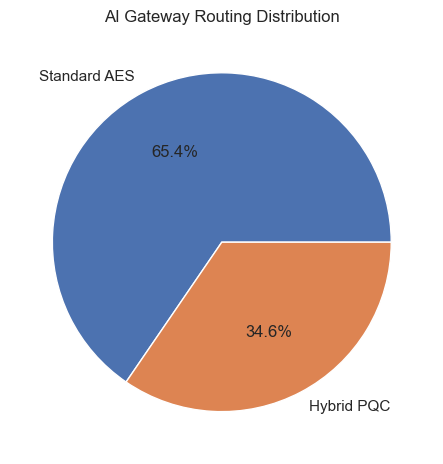

In [63]:
counts = df['algorithm'].value_counts()
plt.figure()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title('AI Gateway Routing Distribution')
plt.tight_layout()
plt.savefig('charts/fig4_ai_distribution.png', dpi=300)
plt.show()

## Graph 5: Latency Variance

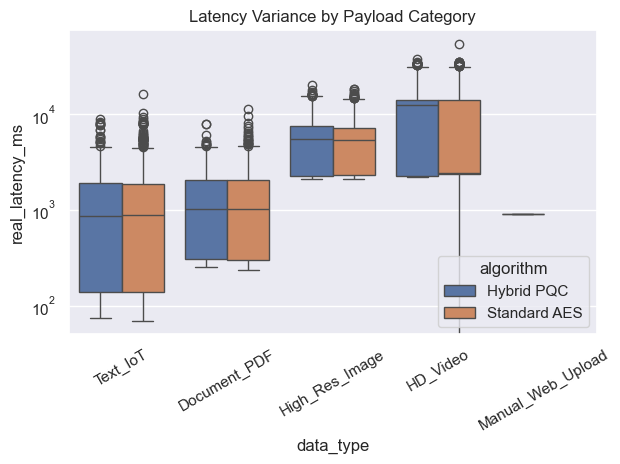

In [64]:
plt.figure()
sns.boxplot(data=df, x='data_type', y='real_latency_ms', hue='algorithm')
plt.yscale('log'); plt.xticks(rotation=30)
plt.title('Latency Variance by Payload Category')
plt.tight_layout()
plt.savefig('charts/fig5_latency_variance.png', dpi=300)
plt.show()

## Graph 6: ECDF

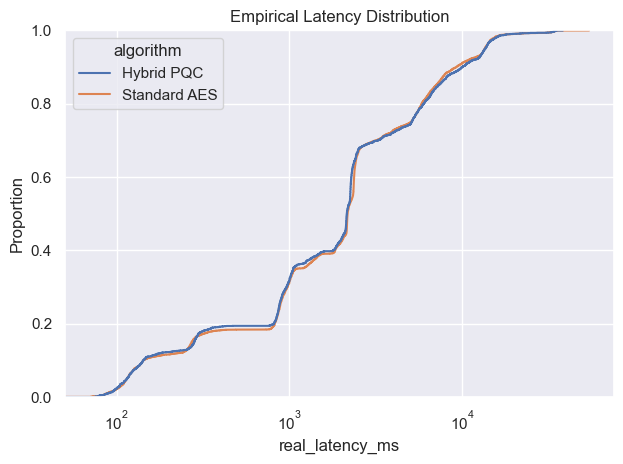

In [65]:
plt.figure()
sns.ecdfplot(data=df, x='real_latency_ms', hue='algorithm')
plt.xscale('log')
plt.title('Empirical Latency Distribution')
plt.tight_layout()
plt.savefig('charts/fig6_latency_ecdf.png', dpi=300)
plt.show()

## Graph 7: Throughput

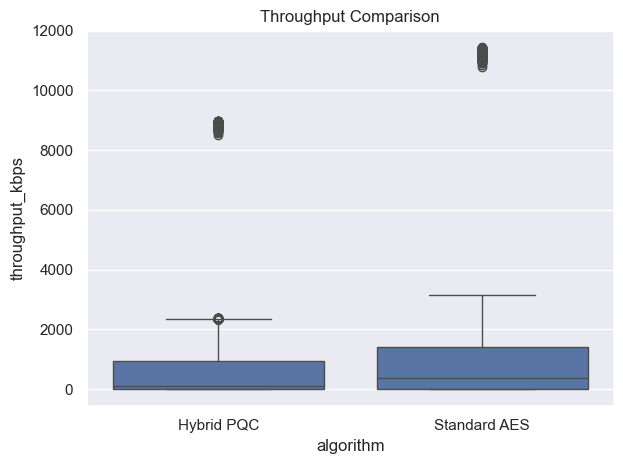

In [66]:
df['throughput_kbps'] = df['size_kb'] / (df['real_latency_ms']/1000)
plt.figure()
sns.boxplot(data=df, x='algorithm', y='throughput_kbps')
plt.title('Throughput Comparison')
plt.tight_layout()
plt.savefig('charts/fig7_throughput.png', dpi=300)
plt.show()

## Graph 8: Security vs Performance

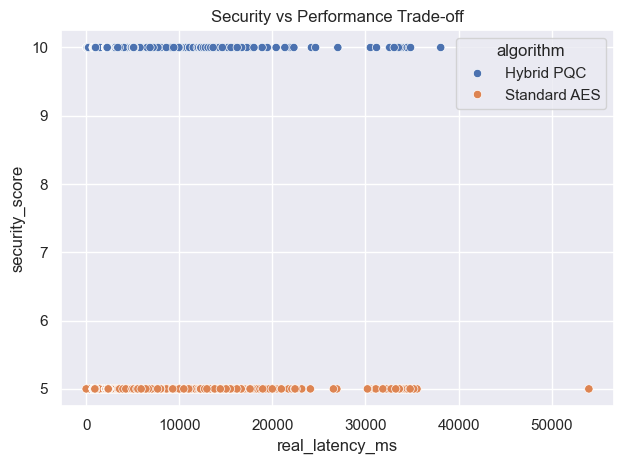

In [67]:
df['security_score'] = df['algorithm'].apply(lambda x: 10 if 'PQC' in x else 5)
plt.figure()
sns.scatterplot(data=df, x='real_latency_ms', y='security_score', hue='algorithm')
plt.title('Security vs Performance Trade-off')
plt.tight_layout()
plt.savefig('charts/fig8_security_vs_performance_tradeoff.png', dpi=300)
plt.show()

## Graph 9: Tail Latency Comparison

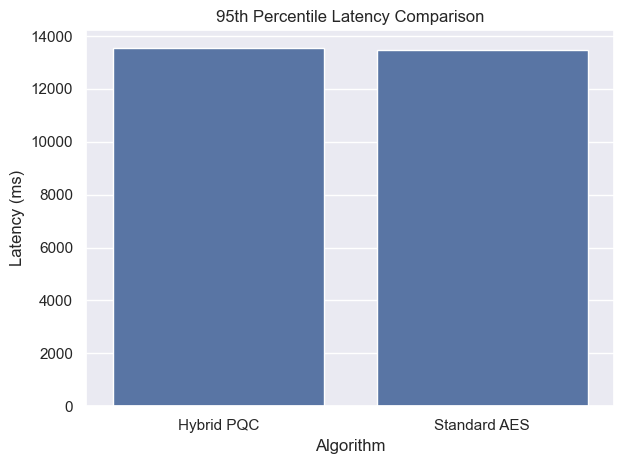

In [68]:
plt.figure()
sns.barplot(data=tail_latency, x='Algorithm', y='Latency_95th_Percentile')
plt.title('95th Percentile Latency Comparison')
plt.ylabel('Latency (ms)')
plt.tight_layout()
plt.savefig('charts/fig9_tail_latency.png', dpi=300)

## Graph 10: Throughput vs Size

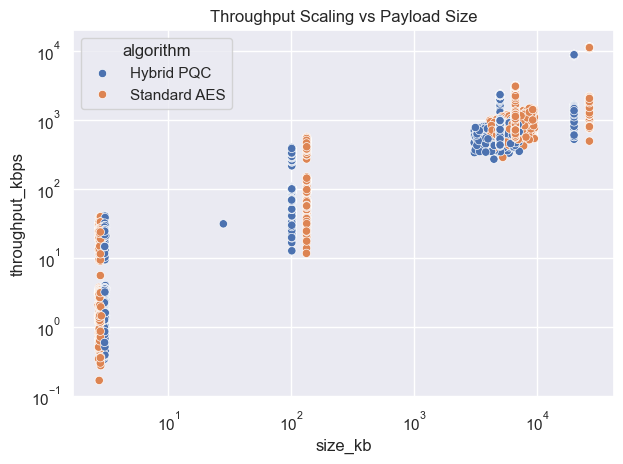

In [69]:
plt.figure()
sns.scatterplot(data=df, x='size_kb', y='throughput_kbps', hue='algorithm')
plt.xscale('log'); plt.yscale('log')
plt.title('Throughput Scaling vs Payload Size')
plt.tight_layout()
plt.savefig('charts/fig10_throughput_scaling.png', dpi=300)